## 1. The Black-Scholes Model and Analytical Solution

The Black-Scholes model is a partial differential equation (PDE) used to determine the fair price of European call options. Below is the formal derivation and its corresponding analytical and numerical representations.

### 1.1 Derivation of the Black-Scholes PDE

Consider a continuous-time portfolio $\Pi$ consisting of a long position in one European call option $C(S,t)$ and a short position of $\Delta$ shares of the underlying asset $S$:

$$\Pi = C - \Delta S$$

Over an infinitesimal time increment $dt$, the change in the portfolio's value is:

$$d\Pi = dC - \Delta dS$$

We assume that the underlying stock price follows a Geometric Brownian Motion (GBM) under the physical probability measure:

$$dS = \mu S dt + \sigma S dW_t$$

where $\mu$ is the expected physical return, $\sigma$ is the volatility, and $W_t$ is a standard Brownian motion. 

Applying **Itô's Lemma** to $C(S, t)$, the total differential $dC$ is given by:

$$dC = \left( \frac{\partial C}{\partial t} + \mu S \frac{\partial C}{\partial S} + \frac{1}{2} \sigma^2 S^2 \frac{\partial^2 C}{\partial S^2} \right) dt + \sigma S \frac{\partial C}{\partial S} dW_t$$

Substituting $dS$ and $dC$ back into the portfolio differential yields:

$$d\Pi = \left( \frac{\partial C}{\partial t} + \mu S \frac{\partial C}{\partial S} + \frac{1}{2} \sigma^2 S^2 \frac{\partial^2 C}{\partial S^2} - \Delta \mu S \right) dt + \sigma S \left( \frac{\partial C}{\partial S} - \Delta \right) dW_t$$

To eliminate the stochastic risk driven by $dW_t$ (making the portfolio completely risk-free), we set the hedge ratio to the option's delta:

$$\Delta = \frac{\partial C}{\partial S}$$

This simplifies the portfolio dynamic to a purely deterministic equation:

$$d\Pi = \left( \frac{\partial C}{\partial t} + \frac{1}{2} \sigma^2 S^2 \frac{\partial^2 C}{\partial S^2} \right) dt$$

Under the assumption of a continuous, replication-based **no-arbitrage market**, a completely risk-free portfolio must yield exactly the risk-free rate of return $r$. Thus, $d\Pi = r \Pi dt$. Expanding this definition:

$$d\Pi = r (C - \Delta S) dt = r \left( C - S \frac{\partial C}{\partial S} \right) dt$$

Equating our two expressions for $d\Pi$ yields the classic **Black-Scholes PDE**:

$$\frac{\partial C}{\partial t} + r S \frac{\partial C}{\partial S} + \frac{1}{2} \sigma^2 S^2 \frac{\partial^2 C}{\partial S^2} - rC = 0$$

Where:
*   $r$: The risk-free interest rate.
*   $\sigma$: The asset volatility.
*   $S$: The spot price of the underlying asset.
*   $t$: The current time coordinate ($0 \le t \le T$).

---

### 1.2 Analytical Solution (European Call Option)

For a terminal condition defined by the European call payoff at maturity $T$, given by $C(S, T) = \max(S - K, 0)$ where $K$ is the strike price, solving the PDE analytically yields:

$$C(S, t) = S \cdot N(d_1) - K e^{-r(T - t)} \cdot N(d_2)$$

Where $N(x)$ represents the standard normal cumulative distribution function (CDF), and the dimensionless parameters $d_1$ and $d_2$ are defined as:

$$d_1 = \frac{\ln\left(\frac{S}{K}\right) + \left(r + \frac{\sigma^2}{2}\right)(T - t)}{\sigma \sqrt{T - t}}$$

$$d_2 = d_1 - \sigma \sqrt{T - t} = \frac{\ln\left(\frac{S}{K}\right) + \left(r - \frac{\sigma^2}{2}\right)(T - t)}{\sigma \sqrt{T - t}}$$



In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

In [2]:
r = 0.05       # Risk-free rate
sigma = 0.20   # Volatility
K = 100        # Strike price
T = 1          # Time to maturity (1 year)

In [3]:
# Solving Black Scholes Analytically
def BS(r, sigma, S0, K, T):
    d1 = (np.log(S0 / K) + (r + sigma**2 / 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    N_d1 = norm.cdf(d1, 0, 1)
    N_d2 = norm.cdf(d2, 0, 1)
    C = S0 * N_d1 - K * np.exp(-r * T)* N_d2
    return C


def plot_3d(r, sigma, K):
    time = np.linspace(0.01, 0.95, 9)
    S0_vals = np.linspace(50, 150, 50)
    S, t = np.meshgrid(S0_vals, time)
    fig, ax = plt.subplots(figsize=(11, 8), subplot_kw={"projection": "3d"})
    Z = BS(r, sigma, S, K, t)
    surf1 = ax.plot_surface(S, t, Z, cmap='viridis', edgecolor='none', label='Analytical')
    ax.view_init(elev=30, azim=-110, roll=0)
    ax.set_title("Call Option Surface")
    ax.set_xlabel("Stock Price")
    ax.set_ylabel("Time")
    ax.set_zlabel("Option Price")
    ax.legend()

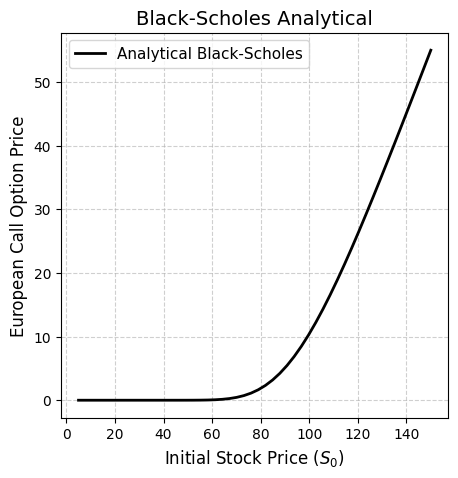

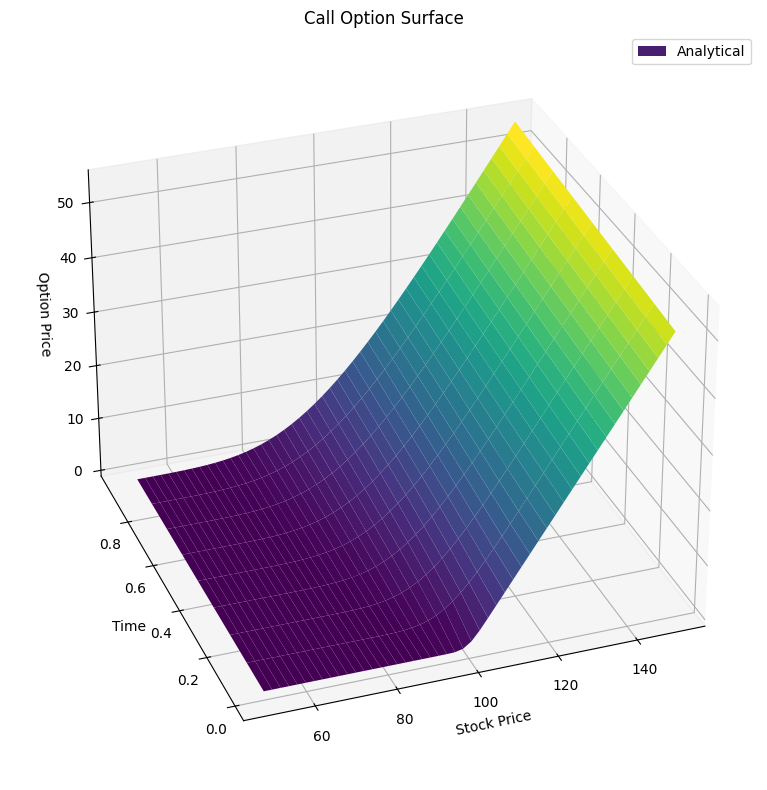

In [4]:
S0_vals = np.linspace(5, 150, 50)
bs_analytical = [BS(r, sigma, s, K, T) for s in S0_vals]
# --- Plotting ---
fig, ax = plt.subplots(figsize=(5,5))

# Analytical solution curve
ax.plot(S0_vals, bs_analytical, label='Analytical Black-Scholes', color='black', linewidth=2)

ax.set_title('Black-Scholes Analytical', fontsize=14)
ax.set_xlabel('Initial Stock Price ($S_0$)', fontsize=12)
ax.set_ylabel('European Call Option Price', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(fontsize=11)

plot_3d(r, sigma, K)
plt.tight_layout()




### 1.3 Monte Carlo Pricing Solution

Alternatively, the pricing problem can be framed via the risk-neutral pricing measure $\mathbb{Q}$. The fair option price at time $t=0$ is the discounted expected value of its terminal payoff:

$$C(S_0, 0) = e^{-rT} \mathbb{E}_\mathbb{Q} \left[ \max(S_T - K, 0) \right]$$

Under the risk-neutral probability measure $\mathbb{Q}$, the asset price dynamic substitutes the physical drift $\mu$ with the risk-free rate $r$. Integrating this stochastic differential equation gives the analytical expression for the terminal stock price $S_T$:

$$S_T = S_0 \exp\left( \left(r - \frac{1}{2}\sigma^2\right)T + \sigma \sqrt{T} Z \right)$$

where $Z \sim \mathcal{N}(0, 1)$ is a standard normal random variable. 

By simulating $M$ independent sampling trajectories of $Z$ (denoted as $Z^{(i)}$), the continuous expectation is numerically approximated via Monte Carlo integration:

$$C(S_0, 0) \approx \frac{e^{-rT}}{M} \sum_{i=1}^{M} \max\left( S_0 \exp\left( \left(r - \frac{1}{2}\sigma^2\right)T + \sigma \sqrt{T} Z^{(i)} \right) - K, \, 0 \right)$$

In [5]:
# Path Generation for Visualization
def generate_path(r, sigma, S0, T, num_paths, num_steps):
    Z = np.random.standard_normal()
    dt = T / num_steps
    time_grid = np.linspace(0, T, num_steps + 1)
    paths = np.zeros((num_steps + 1, num_paths))
    paths[0] = S0
    Z = np.random.standard_normal((num_steps, num_paths))
    for t in range(1, num_steps + 1):
        paths[t] = paths[t-1] * np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z[t-1])
        
    return time_grid, paths


# Solving Black Scholes Using Monte Carlo
def BS_MC(r, sigma, S0, K, T, num_samples):
    Z = np.random.standard_normal(num_samples)
    ST = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
    payoff = np.maximum(ST - K, 0)
    return np.exp(-r * T) * np.mean(payoff)

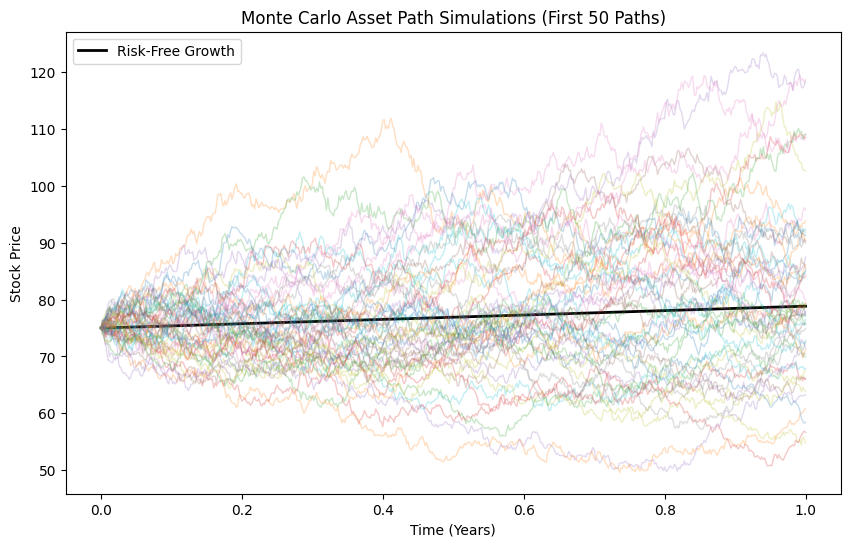

In [6]:
S0 = 75   # Initial stock price
time, paths = generate_path(r, sigma, S0, T, 50, 500)
risk_free_path = S0 * np.exp(time * r)
plt.figure(figsize=(10, 6))
plt.plot(time, risk_free_path, color='black', label='Risk-Free Growth', linewidth=2.0, alpha=1.0)
plt.plot(time, paths[:, :50], alpha=0.25, linewidth=1)
plt.title(f"Monte Carlo Asset Path Simulations (First 50 Paths)")
plt.xlabel("Time (Years)")
plt.ylabel("Stock Price")
plt.legend()
plt.show()

In [7]:
# Range of initial stock prices to plot
S0_vals = np.linspace(50, 150, 50)
bs_analytical = [BS(r, sigma, s, K, T) for s in S0_vals]
N_low = 100
N_high = 10000
bs_mc_low = [BS_MC(r, sigma, s, K, T, N_low) for s in S0_vals]
bs_mc_high = [BS_MC(r, sigma, s, K, T, N_high) for s in S0_vals]

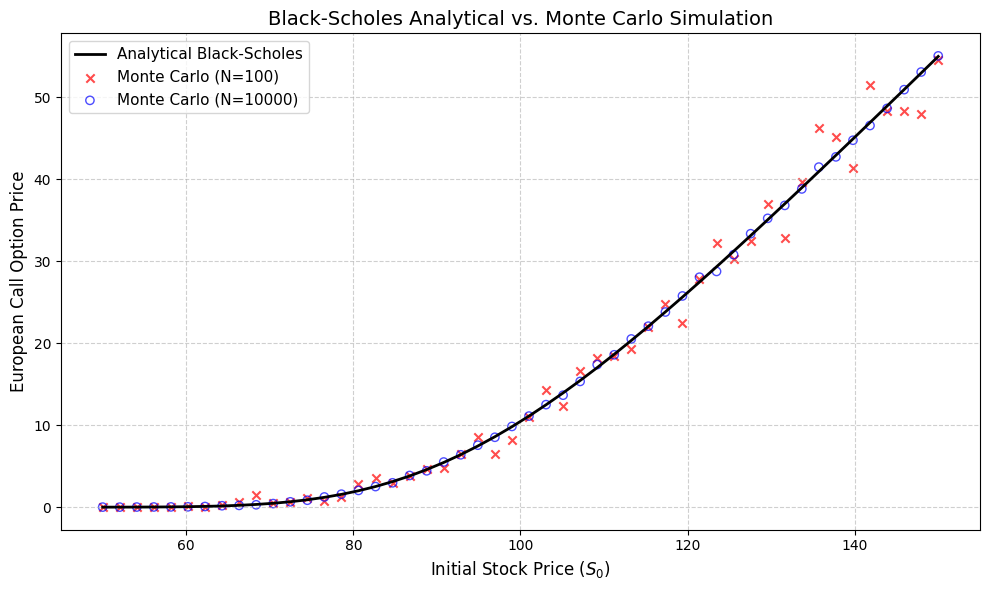

In [8]:
# --- Plotting ---
fig, ax = plt.subplots(figsize=(10, 6))

# Analytical solution curve
ax.plot(S0_vals, bs_analytical, label='Analytical Black-Scholes', color='black', linewidth=2)

# Monte Carlo with low paths 
ax.scatter(S0_vals, bs_mc_low, label=f'Monte Carlo (N={N_low})', color='red', marker='x', alpha=0.7)

# Monte Carlo with high paths 
ax.scatter(S0_vals, bs_mc_high, label=f'Monte Carlo (N={N_high})', color='blue', marker='o', 
           facecolors='none', edgecolors='blue', alpha=0.7)

ax.set_title('Black-Scholes Analytical vs. Monte Carlo Simulation', fontsize=14)
ax.set_xlabel('Initial Stock Price ($S_0$)', fontsize=12)
ax.set_ylabel('European Call Option Price', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(fontsize=11)

plt.tight_layout()